<div style="background:linear-gradient(135deg,#0a2540 0%,#1a3a5c 60%,#0f3460 100%);
            padding:40px 30px;border-radius:12px;margin-bottom:20px">
  <h1 style="color:#ffffff;font-size:2.2em;margin:0 0 8px 0">
    🧬 Clasificación QSAR basada en Docking: Activos vs Decoys
  </h1>
  <p style="color:#a8c4e0;font-size:1.1em;margin:0">
    NB-ML-03 · Fingerprints ProLIF · XGBoost · Dark Chemical Matter · UNAL 2026
  </p>
</div>


---
## Objetivo del notebook

Construimos un clasificador que aprende a distinguir **activos reales** (inhibidores
de ChEMBL) de **decoys** (moléculas con propiedades similares pero scaffolds distintos)
a partir de sus **fingerprints de interacción ProLIF** en el sitio de unión.

### Pipeline completo

```
molecules_prepared.csv (activos ChEMBL con PDBQT)
    ↓ Scaffolds genéricos (MakeScaffoldGeneric)
    ↓ Selección de decoys: Dark Chemical Matter (DCM) con propiedades similares, scaffolds distintos
    ↓ Docking Vina (mismos parámetros que NB-DOCK-02)
    ↓ ProLIF fingerprints (activos + decoys)
    ↓ DataFrame combinado con etiqueta activity (1=activo, 0=decoy)
    ↓ 3 splits: random · scaffold · fingerprint
    ↓ XGBoost (F1, MCC, Balanced Accuracy)
    ↓ Predicción sobre Dark Chemical Matter (DCM) (30 moléculas)
```


---
## 1. Instalación y configuración

In [ ]:
# ── Instalar librerías ───────────────────────────────────────────────────────
!pip install rdkit prolif meeko vina xgboost deepchem scikit-learn pandas numpy matplotlib seaborn tqdm joblib gemmi --quiet
print("✅ Librerías instaladas")


In [1]:
# ── Importaciones ────────────────────────────────────────────────────────────
import os, json, warnings, requests, io
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from tqdm.auto import tqdm
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
import prolif as plf
from meeko import MoleculePreparation
from vina import Vina

try:
    import xgboost as xgb
    XGB_OK = True
    print(f"✅ XGBoost {xgb.__version__}")
except ImportError:
    XGB_OK = False

print("✅ Importaciones completadas")


/home/dfvic/.local/lib/python3.14/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


✅ XGBoost 3.2.0
✅ Importaciones completadas


In [2]:
# ── Parámetros del sistema + descarga de archivos necesarios ─────────────────
import requests, os, json
import numpy as np

PDB_ID        = '7WJO'
LIGAND_CODE   = 'BGI'
TARGET_NAME   = 'TRPV1'

protein_directory = 'estructuras'
pdbqt_directory   = 'pdbqt'
docks_directory   = 'docking'
decoys_directory  = 'docking_decoys'

for d in [protein_directory, pdbqt_directory, docks_directory,
          decoys_directory, 'mols', 'results']:
    os.makedirs(d, exist_ok=True)

BASE = "https://raw.githubusercontent.com/FelPVic/curso_datascience/main/files"

# Todos los SDFs de activos disponibles en el repo
CHEMBL_IDS = [
    'CHEMBL1791178','CHEMBL1791436','CHEMBL265094','CHEMBL285056',
    'CHEMBL285445','CHEMBL287110','CHEMBL287375','CHEMBL32125',
    'CHEMBL32495','CHEMBL32687','CHEMBL32780','CHEMBL34818',
    'CHEMBL35306','CHEMBL35365','CHEMBL35516','CHEMBL35671',
    'CHEMBL35735','CHEMBL35760','CHEMBL35895','CHEMBL36240',
    'CHEMBL36409','CHEMBL36445','CHEMBL36446','CHEMBL412808',
    'CHEMBL416596','CHEMBL422402','CHEMBL443517','CHEMBL4741395',
    'CHEMBL4786444',
]

archivos_necesarios = {
    # estructuras
    f'{protein_directory}/7WJO_a.pdb':         f'{BASE}/estructuras/7WJO_a.pdb',
    f'{protein_directory}/7WJO_a_clean.pdb':   f'{BASE}/estructuras/7WJO_a_clean.pdb',
    f'{protein_directory}/BGI_org.sdf':         f'{BASE}/estructuras/BGI_org.sdf',
    f'{protein_directory}/BGI_org.pdb':         f'{BASE}/estructuras/BGI_org.pdb',
    f'{protein_directory}/docking_params.json': f'{BASE}/estructuras/docking_params.json',
    f'{protein_directory}/protein_h.pdb':       f'{BASE}/estructuras/protein_h.pdb',
    # pdbqt
    f'{pdbqt_directory}/7WJO.pdbqt':           f'{BASE}/pdbqt/7WJO.pdbqt',
    f'{pdbqt_directory}/BGI.pdbqt':            f'{BASE}/pdbqt/BGI.pdbqt',
    # SDFs de activos
    **{f'{docks_directory}/{c}.sdf': f'{BASE}/docking/{c}.sdf' for c in CHEMBL_IDS},
    # CSVs
    'fps_activos.csv':        f'{BASE}/docking/fps_activos.csv',
    'molecules_prepared.csv': f'{BASE}/mols/molecules_prepared.csv',
}

print("Verificando y descargando archivos del repositorio...")
print("=" * 60)
descargados, existentes, fallidos = 0, 0, 0

for destino, url in archivos_necesarios.items():
    if os.path.exists(destino):
        existentes += 1
        continue
    nombre = os.path.basename(destino)
    try:
        r = requests.get(url, timeout=120)
        if r.status_code == 200:
            with open(destino, 'wb') as fh:
                fh.write(r.content)
            print(f"  📥 {nombre:<45} ({len(r.content)/1024:.1f} KB)")
            descargados += 1
        else:
            print(f"  ❌ {nombre:<45} HTTP {r.status_code}")
            fallidos += 1
    except Exception as e:
        print(f"  ❌ {nombre:<45} {e}")
        fallidos += 1

print()
print(f"  ✅ Ya existían: {existentes}  |  📥 Descargados: {descargados}  |  ❌ Fallidos: {fallidos}")

# Cargar parámetros de docking
params_path = f'{protein_directory}/docking_params.json'
if os.path.exists(params_path):
    with open(params_path) as fh:
        dp = json.load(fh)
    pocket_center = np.array(dp['pocket_center'])
    ligand_box    = np.array(dp['ligand_box'])
    print(f"\n✅ Parámetros de docking cargados:")
    print(f"   Centro: {pocket_center}")
    print(f"   Caja:   {ligand_box}")
else:
    print("\n⚠️  docking_params.json no encontrado — define manualmente:")
    pocket_center = np.array([0.0, 0.0, 0.0])
    ligand_box    = np.array([20.0, 20.0, 20.0])


Verificando y descargando archivos del repositorio...

  ✅ Ya existían: 39  |  📥 Descargados: 0  |  ❌ Fallidos: 0

✅ Parámetros de docking cargados:
   Centro: [20.34785723 11.4522856  17.00051422]
   Caja:   [12.62099934  9.88699913 15.08899975]


---
## 2. Scaffolds genéricos de los activos ChEMBL

Calculamos el **scaffold genérico** (MakeScaffoldGeneric) de cada activo —
elimina todos los heteroátomos y sustituye con carbonos, dejando solo la topología
del esqueleto. Esto permite una comparación más robusta que el scaffold de Murcko
para identificar decoys estructuralmente distintos.


In [3]:
# ── Cargar activos preparados ────────────────────────────────────────────────
# Desde archivo local o desde GitHub
ARCHIVO_MOL = 'molecules_prepared.csv'
URL_MOL = ("https://raw.githubusercontent.com/FelPVic/curso_datascience/"
           "main/files/molecules_prepared.csv")

if os.path.exists(ARCHIVO_MOL):
    df_activos = pd.read_csv(ARCHIVO_MOL)
    print(f"✅ Activos cargados localmente: {len(df_activos)}")
else:
    print("Descargando molecules_prepared.csv desde GitHub...")
    df_activos = pd.read_csv(URL_MOL)
    print(f"✅ Activos cargados desde GitHub: {len(df_activos)}")

# Normalizar columna de pActividad
if 'pValue' in df_activos.columns and 'pActividad' not in df_activos.columns:
    df_activos = df_activos.rename(columns={'pValue': 'pActividad'})

df_activos = df_activos.dropna(subset=['std_smiles']).reset_index(drop=True)
print(f"   Columnas: {df_activos.columns.tolist()}")


✅ Activos cargados localmente: 29
   Columnas: ['canonical_smiles', 'molecule_chembl_id', 'pchembl_value', 'standard_type', 'standard_units', 'standard_value', 'type', 'units', 'value', 'pActividad', 'mol_weight', 'std_smiles', 'cur_error', 'pdbqt']


In [4]:
# ── Calcular scaffolds genéricos de los activos ──────────────────────────────
def scaffold_generico(smiles):
    """
    Calcula el scaffold genérico (MakeScaffoldGeneric):
    - Extrae el scaffold de Murcko (elimina cadenas laterales)
    - Reemplaza todos los heteroátomos por C (genérico)
    - Convierte todos los enlaces a simples (topología pura)
    Retorna el SMILES del scaffold o None si falla.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        # Paso 1: Murcko scaffold
        core = MurckoScaffold.GetScaffoldForMol(mol)
        # Paso 2: scaffold genérico
        generic = MurckoScaffold.MakeScaffoldGeneric(core)
        return Chem.MolToSmiles(generic)
    except Exception:
        return None

df_activos['scaffold_murcko'] = df_activos['std_smiles'].apply(
    lambda s: Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(
        Chem.MolFromSmiles(s))) if Chem.MolFromSmiles(s) else None
)
df_activos['scaffold_generico'] = df_activos['std_smiles'].apply(scaffold_generico)

scaffolds_activos = set(df_activos['scaffold_generico'].dropna().tolist())

print(f"Activos:                  {len(df_activos)}")
print(f"Scaffolds genéricos únicos: {len(scaffolds_activos)}")
print()
print("Ejemplos de scaffolds genéricos:")
for scf in list(scaffolds_activos)[:3]:
    print(f"  {scf}")


Activos:                  29
Scaffolds genéricos únicos: 7

Ejemplos de scaffolds genéricos:
  C1CCCCC1
  C1CCC2CCCCC2C1
  CC1CCC2C(CCC3CCCCC3)CCCC2C1


---
## 3. Selección de decoys desde Dark Chemical Matter (DCM)

Los **Dark Chemical Matter** son compuestos que han sido testados en múltiples
ensayos de HTS pero nunca han mostrado actividad — son negativos confiables.
Son ideales como decoys porque:

1. **Tienen actividad confirmada como INACTIVOS** en múltiples targets
2. Cubren un espacio químico diverso
3. Ya vienen preparados con scaffolds genéricos calculados (columna `scf`)

Fuente: [SmartDock — Koch Group](https://github.com/kochgroup/smartdock)


In [5]:
# ── Descargar y cargar Dark Chemical Matter (DCM) ────────────────────────────
URL_DCM = ("https://raw.githubusercontent.com/kochgroup/smartdock/"
           "main/.src/DCM_prepared.csv")

ARCHIVO_DCM = 'DCM_prepared.csv'
if os.path.exists(ARCHIVO_DCM):
    df_dcm = pd.read_csv(ARCHIVO_DCM)
    print(f"✅ DCM cargado localmente: {len(df_dcm)} moléculas")
else:
    print("Descargando Dark Chemical Matter desde GitHub (Koch Group)...")
    r = requests.get(URL_DCM, timeout=120)
    if r.status_code == 200:
        with open(ARCHIVO_DCM, 'wb') as fh:
            fh.write(r.content)
        df_dcm = pd.read_csv(ARCHIVO_DCM)
        print(f"✅ DCM descargado y cargado: {len(df_dcm)} moléculas")
    else:
        raise ConnectionError(f"No se pudo descargar DCM: HTTP {r.status_code}")

# El CSV ya tiene la columna 'scf' (scaffold genérico) calculada
print(f"   Columnas: {df_dcm.columns.tolist()}")
print()
print(df_dcm.head(3)[['molecule_chembl_id','smiles','molwt','scf']].to_string(index=False))


✅ DCM cargado localmente: 119185 moléculas
   Columnas: ['InChI_Key', 'set', 'smiles', 'molecule_chembl_id', 'molwt', 'scf', 'id']

molecule_chembl_id                                              smiles   molwt                                    scf
     CHEMBL1605650 C[C@@H]1CCC[C@H](C)N1NC(=O)c1ccc(Cl)c(S(N)(=O)=O)c1 345.852 CC(CC1C(C)CCCC1C)C1CCC(C)C(C(C)(C)C)C1
     CHEMBL1713382                         Cc1ccc(N=C(N)N=C(N)N)c(C)c1 205.265                CC(C)CC(C)CC1CCC(C)CC1C
     CHEMBL1437772                          CC(=O)N1c2ccccc2Sc2ccccc21 241.315              CC(C)C1C2CCCCC2CC2CCCCC21


In [6]:
# ── Calcular propiedades de activos para el filtro de matching ────────────────
from rdkit.Chem import Descriptors

def calc_props(mol):
    return {
        'MW':   Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBD':  Descriptors.NumHDonors(mol),
        'HBA':  Descriptors.NumHAcceptors(mol),
    }

# Propiedades de los activos ChEMBL
props_activos = []
for smi in df_activos['std_smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        props_activos.append(calc_props(mol))
df_props_act = pd.DataFrame(props_activos)

# Rangos ±20% de tolerancia sobre los activos
rangos = {}
for col in ['MW','LogP','TPSA','HBD','HBA']:
    mn, mx   = df_props_act[col].min(), df_props_act[col].max()
    margen   = (mx - mn) * 0.20
    rangos[col] = (mn - margen, mx + margen)

print("Rangos de propiedades de activos (±20%):")
for k, (lo, hi) in rangos.items():
    print(f"  {k:<6}: [{lo:.2f}, {hi:.2f}]")

# Calcular propiedades del DCM
# DCM ya tiene molwt → usarla directamente, calcular el resto
print("\nCalculando propiedades del DCM...")
dcm_props = []
for smi in tqdm(df_dcm['smiles'], desc='Props DCM'):
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        dcm_props.append(calc_props(mol))
    else:
        dcm_props.append({k: np.nan for k in ['MW','LogP','TPSA','HBD','HBA']})

df_dcm_props = pd.DataFrame(dcm_props)
df_dcm = pd.concat([df_dcm.reset_index(drop=True), df_dcm_props], axis=1)

# Filtrar por propiedades fisicoquímicas similares a los activos
mask = pd.Series([True] * len(df_dcm))
for col, (lo, hi) in rangos.items():
    mask = mask & (df_dcm[col] >= lo) & (df_dcm[col] <= hi)

df_dcm_filt = df_dcm[mask].dropna(subset=['smiles']).reset_index(drop=True)
print(f"\nDCM tras filtro de propiedades: {len(df_dcm_filt)} / {len(df_dcm)} moléculas")


Rangos de propiedades de activos (±20%):
  MW    : [158.29, 900.85]
  LogP  : [-8.76, 7.51]
  TPSA  : [-41.94, 426.09]
  HBD   : [-1.00, 13.00]
  HBA   : [-0.40, 16.40]

Calculando propiedades del DCM...


Props DCM:   0%|          | 0/119185 [00:00<?, ?it/s]


DCM tras filtro de propiedades: 119060 / 119185 moléculas


In [7]:
# ── Filtrar por scaffold genérico distinto a los activos ─────────────────────
# DCM ya tiene la columna 'scf' con el scaffold genérico calculado
# No necesitamos recalcularla — ahorramos tiempo

# Excluir compuestos cuyo scaffold coincida con algún activo
mask_nuevo_scf = ~df_dcm_filt['scf'].isin(scaffolds_activos)
df_decoys_cand = df_dcm_filt[mask_nuevo_scf].reset_index(drop=True)

# Un representante por scaffold (máxima diversidad estructural)
df_decoys_cand = (df_decoys_cand
                  .dropna(subset=['scf'])
                  .drop_duplicates(subset='scf')
                  .reset_index(drop=True))

# Limitar a máximo 2× el número de activos
N_DECOYS_MAX = min(len(df_activos) * 2, len(df_decoys_cand))
df_decoys    = df_decoys_cand.sample(N_DECOYS_MAX, random_state=42).reset_index(drop=True)

# Normalizar nombres de columnas para el resto del notebook
df_decoys = df_decoys.rename(columns={
    'smiles':           'std_smiles',
    'molecule_chembl_id':'molecule_id',
    'scf':              'scaffold_generico',
})

print(f"Activos:              {len(df_activos)}")
print(f"DCM disponibles:      {len(df_dcm_filt)}")
print(f"Decoys seleccionados: {len(df_decoys)}  (un scaffold único por compuesto)")
print(f"Ratio decoys/activos: {len(df_decoys)/len(df_activos):.1f}x")
print()
print(f"Ejemplos de scaffolds DCM seleccionados:")
for scf in df_decoys['scaffold_generico'].head(3).tolist():
    print(f"  {scf}")


Activos:              29
DCM disponibles:      119060
Decoys seleccionados: 58  (un scaffold único por compuesto)
Ratio decoys/activos: 2.0x

Ejemplos de scaffolds DCM seleccionados:
  CC(CC1CCC(C(C)(C)CCC2CCCCC2)CC1)CC1CCCCC1C1CCCCC1
  CC1CC(C(C)C2CCC2(C)C(C)CCC2CCCC3CCCCC32)CC1C
  CC1CCC(CC2C3CC(C)CCC3CC2C2CCCCC2)CC1


In [8]:
# ── Seleccionar 4 decoys por cada activo (matching 1:4) ─────────────────────
import numpy as np

def seleccionar_decoys_por_activo(df_activos, df_decoys_candidatos,
                                   n_decoys_por_activo=4, random_state=42):
    """
    Selecciona n_decoys_por_activo decoys para cada activo usando
    matching por propiedades fisicoquímicas más cercanas.

    Para cada activo:
      1. Calcula la distancia euclídea normalizada en el espacio MW/LogP/TPSA
      2. Toma los n_decoys_por_activo decoys más cercanos que aún no hayan
         sido asignados (sin reemplazamiento entre activos)

    Parámetros
    ----------
    df_activos            : DataFrame con columna 'std_smiles'
    df_decoys_candidatos  : DataFrame con columnas 'std_smiles' y 'scaffold_generico'
    n_decoys_por_activo   : int — número de decoys por activo (default 4)
    random_state          : int — semilla para reproducibilidad

    Retorna
    -------
    df_decoys_sel : DataFrame con los decoys seleccionados y columna 'activo_match'
    """
    from sklearn.preprocessing import StandardScaler
    from rdkit.Chem import Descriptors

    np.random.seed(random_state)

    def props(smiles):
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None
        return np.array([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
        ], dtype=float)

    # Calcular propiedades de activos
    props_act = []
    ids_act   = []
    for _, row in df_activos.iterrows():
        p = props(row['std_smiles'])
        if p is not None:
            props_act.append(p)
            ids_act.append(row.get('molecule_chembl_id', f'activo_{_}'))

    # Calcular propiedades de decoys candidatos
    props_dec = []
    idx_dec   = []
    for i, row in df_decoys_candidatos.iterrows():
        p = props(row['std_smiles'])
        if p is not None:
            props_dec.append(p)
            idx_dec.append(i)

    X_act = np.array(props_act)
    X_dec = np.array(props_dec)

    # Escalar conjuntamente
    scaler  = StandardScaler()
    X_todos = scaler.fit_transform(np.vstack([X_act, X_dec]))
    X_act_s = X_todos[:len(X_act)]
    X_dec_s = X_todos[len(X_act):]

    disponibles  = set(range(len(X_dec_s)))
    seleccionados = []

    for i, (act_vec, act_id) in enumerate(zip(X_act_s, ids_act)):
        if len(disponibles) < n_decoys_por_activo:
            print(f"⚠️  Pocos decoys disponibles ({len(disponibles)}) para activo {act_id}")
            candidatos_idx = list(disponibles)
        else:
            # Distancia euclídea a todos los decoys disponibles
            dists   = np.linalg.norm(X_dec_s[list(disponibles)] - act_vec, axis=1)
            disp_arr = np.array(list(disponibles))
            # Top n_decoys_por_activo más cercanos
            top_idx = disp_arr[np.argsort(dists)[:n_decoys_por_activo]]
            candidatos_idx = top_idx.tolist()

        # Marcar como usados
        for ci in candidatos_idx:
            disponibles.discard(ci)

        # Guardar con referencia al activo
        for ci in candidatos_idx:
            fila = df_decoys_candidatos.iloc[idx_dec[ci]].copy()
            fila['activo_match'] = act_id
            seleccionados.append(fila)

    df_sel = pd.DataFrame(seleccionados).reset_index(drop=True)
    return df_sel

In [9]:
# ── Verificar columnas disponibles ───────────────────────────────────────────
print("Columnas en df_activos:")
print(f"  {df_activos.columns.tolist()}")
print()
print("Columnas en df_decoys_cand:")
print(f"  {df_decoys_cand.columns.tolist()}")

Columnas en df_activos:
  ['canonical_smiles', 'molecule_chembl_id', 'pchembl_value', 'standard_type', 'standard_units', 'standard_value', 'type', 'units', 'value', 'pActividad', 'mol_weight', 'std_smiles', 'cur_error', 'pdbqt', 'scaffold_murcko', 'scaffold_generico']

Columnas en df_decoys_cand:
  ['InChI_Key', 'set', 'smiles', 'molecule_chembl_id', 'molwt', 'scf', 'id', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA']


In [10]:
# ── Normalizar columnas antes de llamar la función ───────────────────────────
# Activos: asegurar que tiene 'std_smiles'
if 'std_smiles' not in df_activos.columns:
    col_smi_act = next((c for c in df_activos.columns
                        if 'smiles' in c.lower()), None)
    if col_smi_act:
        df_activos = df_activos.rename(columns={col_smi_act: 'std_smiles'})
        print(f"✅ Activos: renombrado '{col_smi_act}' → 'std_smiles'")

# Decoys: asegurar que tiene 'std_smiles'
if 'std_smiles' not in df_decoys_cand.columns:
    col_smi_dec = next((c for c in df_decoys_cand.columns
                        if 'smiles' in c.lower()), None)
    if col_smi_dec:
        df_decoys_cand = df_decoys_cand.rename(columns={col_smi_dec: 'std_smiles'})
        print(f"✅ Decoys: renombrado '{col_smi_dec}' → 'std_smiles'")

# Decoys: asegurar que tiene 'molecule_chembl_id' o 'molecule_id'
if 'molecule_chembl_id' not in df_decoys_cand.columns and \
   'molecule_id' not in df_decoys_cand.columns:
    col_id = next((c for c in df_decoys_cand.columns
                   if 'id' in c.lower()), None)
    if col_id:
        df_decoys_cand = df_decoys_cand.rename(columns={col_id: 'molecule_id'})
        print(f"✅ Decoys: renombrado '{col_id}' → 'molecule_id'")

print()
print(f"Columnas activos:  {df_activos.columns.tolist()}")
print(f"Columnas decoys:   {df_decoys_cand.columns.tolist()}")
print()

# ── Ejecutar selección ────────────────────────────────────────────────────────
df_decoys = seleccionar_decoys_por_activo(
    df_activos,
    df_decoys_cand,
    n_decoys_por_activo=4,
    random_state=42
)

✅ Decoys: renombrado 'smiles' → 'std_smiles'

Columnas activos:  ['canonical_smiles', 'molecule_chembl_id', 'pchembl_value', 'standard_type', 'standard_units', 'standard_value', 'type', 'units', 'value', 'pActividad', 'mol_weight', 'std_smiles', 'cur_error', 'pdbqt', 'scaffold_murcko', 'scaffold_generico']
Columnas decoys:   ['InChI_Key', 'set', 'std_smiles', 'molecule_chembl_id', 'molwt', 'scf', 'id', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA']



---
## 4. Preparación de decoys: conformeros 3D y PDBQT


In [11]:
# ── Función de generación de conformero + conversión a PDBQT ─────────────────
def preparar_ligando(smiles):
    """
    Genera el conformero 3D y convierte a formato PDBQT con Meeko.
    Retorna el string PDBQT o None si falla.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        mol = Chem.AddHs(mol)
        result = AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
        if result != 0:
            result = AllChem.EmbedMolecule(mol,
                AllChem.ETKDGv3(), randomSeed=42)
        if result != 0: return None
        AllChem.MMFFOptimizeMolecule(mol)
        preparator = MoleculePreparation()
        preparator.prepare(mol)
        return preparator.write_pdbqt_string()
    except Exception as e:
        return None

# Preparar decoys
print(f"Preparando {len(df_decoys)} decoys (conformeros 3D + PDBQT)...")
pdbqts_decoys = []
for _, row in tqdm(df_decoys.iterrows(), total=len(df_decoys)):
    pdbqt = preparar_ligando(row['std_smiles'])
    pdbqts_decoys.append(pdbqt)

df_decoys['pdbqt'] = pdbqts_decoys
df_decoys_validos = df_decoys[df_decoys['pdbqt'].notna()].reset_index(drop=True)

print(f"\n✅ Decoys preparados: {len(df_decoys_validos)} / {len(df_decoys)}")
print(f"   Fallidos: {len(df_decoys) - len(df_decoys_validos)}")


Preparando 116 decoys (conformeros 3D + PDBQT)...


  0%|          | 0/116 [00:00<?, ?it/s]

/home/dfvic/.local/lib/python3.14/site-packages/meeko/preparation.py:693: DeprecationWarning: MoleculePreparation.write_pdbqt_string() is deprecated in Meeko v0.5. Pass the MoleculeSetup instance to PDBQTWriterLegacy.write_string(). MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)
/home/dfvic/.local/lib/python3.14/site-packages/meeko/preparation.py:467: DeprecationWarning: MoleculePreparation.setup is deprecated in Meeko v0.5. MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)



✅ Decoys preparados: 116 / 116
   Fallidos: 0


---
## 5. Docking en batch de decoys

Usamos exactamente los mismos parámetros que en NB-ML-02 (misma caja, misma
exhaustiveness) para que los resultados sean comparables.


In [12]:
# ── Función de docking individual ────────────────────────────────────────────
def vina_docking_decoy(mol_id, pdbqt_str, output_dir,
                       center=None, box_size=None,
                       exhaustiveness=8, n_poses=5):
    """Corre Vina para un decoy y guarda el SDF resultado.

    Si center/box_size son None, los carga automáticamente desde
    estructuras/docking_params.json.
    """
    out_sdf = os.path.join(output_dir, f'{mol_id}.sdf')
    if os.path.exists(out_sdf):
        return True   # ya calculado

    # ── Cargar parámetros de docking desde JSON si no se pasaron ─────────────
    if center is None or box_size is None:
        params_path = os.path.join(protein_directory, 'docking_params.json')
        with open(params_path) as fh:
            dp = json.load(fh)
        center   = np.array(dp['pocket_center'])
        box_size = np.array(dp['ligand_box'])

    pdbqt_path = os.path.join(output_dir, f'{mol_id}.pdbqt')
    try:
        with open(pdbqt_path, 'w') as f:
            f.write(pdbqt_str)

        v = Vina(sf_name='vina', verbosity=0)
        v.set_receptor(os.path.join(pdbqt_directory, f'{PDB_ID}.pdbqt'))
        v.set_ligand_from_file(pdbqt_path)
        v.compute_vina_maps(center=center.tolist(),
                            box_size=box_size.tolist())
        v.dock(exhaustiveness=exhaustiveness, n_poses=n_poses)
        v.write_poses(out_sdf, n_poses=n_poses, overwrite=True)
        return True
    except Exception as e:
        return False
    finally:
        if os.path.exists(pdbqt_path):
            os.remove(pdbqt_path)


In [ ]:
# ── Docking en batch ─────────────────────────────────────────────────────────
from joblib import Parallel, delayed

ya_procesados = set(
    os.path.splitext(os.path.basename(f))[0]
    for f in __import__('glob').glob(f'{decoys_directory}/*.sdf')
)
pendientes = df_decoys_validos[
    ~df_decoys_validos['id'].isin(ya_procesados)
]

print(f"Decoys totales:     {len(df_decoys_validos)}")
print(f"Ya procesados:      {len(ya_procesados)}")
print(f"Pendientes:         {len(pendientes)}")

if len(pendientes) == 0:
    print("✅ Todos los dockings ya están calculados")
else:
    n_jobs = min(2, os.cpu_count() or 1)
    print(f"\nIniciando docking ({n_jobs} workers, exhaustiveness=8)...")

    resultados = Parallel(n_jobs=n_jobs, prefer='threads')(
        delayed(vina_docking_decoy)(
            row.id, row.pdbqt, decoys_directory
        )
        for _, row in tqdm(pendientes.iterrows(), total=len(pendientes),
                           desc='Docking decoys')
    )
    exitosos = sum(resultados)
    print(f"\n✅ Docking completado: {exitosos} / {len(pendientes)}")


In [13]:
# ── Descargar resultados de docking pre-calculados desde GitHub ───────────────
# Se ejecuta si el docking local produjo pocos o ningún resultado
import glob as _glob
import time

sdfs_locales = _glob.glob(f'{decoys_directory}/*.sdf')
print(f"SDFs en {decoys_directory}/: {len(sdfs_locales)}")

UMBRAL_DESCARGA = len(df_decoys_validos) // 2   # descargar si tenemos menos del 50%

if len(sdfs_locales) >= UMBRAL_DESCARGA:
    print("✅ Resultados de docking suficientes — no se descarga nada")
else:
    print(f"Pocos resultados locales ({len(sdfs_locales)}). "
          f"Descargando desde GitHub...")

    API_URL = ("https://api.github.com/repos/FelPVic/curso_datascience"
               "/contents/files/docking_decoys")

    r_api = requests.get(API_URL, timeout=60,
                         headers={"Accept": "application/vnd.github.v3+json"})

    if r_api.status_code != 200:
        print(f"❌ GitHub API respondió con HTTP {r_api.status_code}")
        print("   Verifica que la carpeta files/docking_decoys exista en el repo")
    else:
        archivos_gh = r_api.json()
        sdf_entries = [e for e in archivos_gh if e['name'].endswith('.sdf')]
        print(f"   Archivos SDF en GitHub: {len(sdf_entries)}")

        ya_existen = {os.path.basename(p) for p in sdfs_locales}
        por_descargar = [e for e in sdf_entries
                         if e['name'] not in ya_existen]
        print(f"   Por descargar:          {len(por_descargar)}")

        descargados_gh, fallidos_gh = 0, 0
        for entry in tqdm(por_descargar, desc='Descargando SDFs'):
            dest = os.path.join(decoys_directory, entry['name'])
            ok = False
            for intento in range(3):
                try:
                    resp = requests.get(entry['download_url'], timeout=120)
                    if resp.status_code == 200:
                        with open(dest, 'wb') as fh:
                            fh.write(resp.content)
                        descargados_gh += 1
                        ok = True
                        break
                    else:
                        if intento == 2:
                            print(f"\n  ❌ {entry['name']}: HTTP {resp.status_code}")
                except Exception as e:
                    if intento == 2:
                        print(f"\n  ❌ {entry['name']}: {e}")
                    else:
                        time.sleep(2 ** intento)
            if not ok:
                fallidos_gh += 1

        total_sdfs = len(_glob.glob(f'{decoys_directory}/*.sdf'))
        print(f"\n✅ Descargados: {descargados_gh}  |  ❌ Fallidos: {fallidos_gh}")
        print(f"   Total SDFs disponibles: {total_sdfs}")


SDFs en docking_decoys/: 116
✅ Resultados de docking suficientes — no se descarga nada


In [14]:
# ── Verificar SDFs y convertir PDBQT→SDF si es necesario ─────────────────────
# Vina escribe sus poses en formato PDBQT aunque el archivo tenga extensión .sdf.
# Esta celda detecta archivos que no son SDF válidos y los convierte usando
# OpenBabel (misma lógica que pdbqt_to_sdf en NB-ML-02).
import glob as _glob
from openbabel import openbabel as ob

def es_sdf_valido(sdf_path):
    """Retorna True si el archivo contiene al menos 1 molécula parseable por RDKit."""
    try:
        suppl = Chem.SDMolSupplier(sdf_path, removeHs=False, sanitize=False)
        return any(m is not None for m in suppl)
    except Exception:
        return False

def pdbqt_a_sdf(pdbqt_path, smiles, output_path):
    """
    Convierte un archivo PDBQT de Vina a SDF válido con órdenes de enlace correctos.
    Sobreescribe output_path. Retorna True si escribe al menos 1 pose.
    """
    with open(pdbqt_path, 'r') as fh:
        pdbqt_str = fh.read()

    # Extraer scores de las líneas REMARK VINA RESULT
    scores = []
    for linea in pdbqt_str.splitlines():
        if 'VINA RESULT' in linea:
            try:
                scores.append(float(linea.split()[3]))
            except (IndexError, ValueError):
                scores.append(0.0)

    # Separar poses en bloques MODEL...ENDMDL
    model_blocks, current = [], []
    for linea in pdbqt_str.splitlines():
        if linea.startswith('MODEL'):
            current = [linea]
        elif linea.startswith('ENDMDL'):
            if current:
                current.append(linea)
                model_blocks.append('\n'.join(current))
            current = []
        elif current:
            current.append(linea)
    if not model_blocks:
        model_blocks = [pdbqt_str]

    smiles_mol = Chem.MolFromSmiles(smiles) if smiles else None
    escritor = Chem.SDWriter(output_path)
    n_written = 0

    for i, block in enumerate(model_blocks):
        conv = ob.OBConversion()
        conv.SetInAndOutFormats('pdbqt', 'sdf')
        ob_mol = ob.OBMol()
        if not conv.ReadString(ob_mol, block) or ob_mol.NumAtoms() == 0:
            continue
        sdf_str   = conv.WriteString(ob_mol)
        rdkit_mol = Chem.MolFromMolBlock(sdf_str, removeHs=False, sanitize=False)
        if rdkit_mol is None:
            continue
        if smiles_mol is not None:
            try:
                rdkit_mol = AllChem.AssignBondOrdersFromTemplate(smiles_mol, rdkit_mol)
            except Exception:
                pass
        rdkit_mol.SetDoubleProp('vina_score', scores[i] if i < len(scores) else 0.0)
        rdkit_mol.SetIntProp('pose_id', i + 1)
        escritor.write(rdkit_mol)
        n_written += 1

    escritor.close()
    return n_written > 0

# ── Mapa id → SMILES para asignación correcta de órdenes de enlace ────────────
id_a_smiles = {str(row['id']): row['std_smiles']
               for _, row in df_decoys_validos.iterrows()}

# ── Verificar y convertir ─────────────────────────────────────────────────────
sdfs_en_disco = _glob.glob(f'{decoys_directory}/*.sdf')
print(f"Verificando {len(sdfs_en_disco)} archivos en {decoys_directory}/...")
print("=" * 60)

validos, convertidos, fallidos_conv = 0, 0, 0

for sdf_path in tqdm(sdfs_en_disco, desc='Verificando/Convirtiendo'):
    if es_sdf_valido(sdf_path):
        validos += 1
        continue
    mol_id = os.path.splitext(os.path.basename(sdf_path))[0]
    smiles = id_a_smiles.get(mol_id, '')
    ok = pdbqt_a_sdf(sdf_path, smiles, sdf_path)
    if ok:
        convertidos += 1
    else:
        fallidos_conv += 1
        print(f"  ❌ No se pudo convertir: {os.path.basename(sdf_path)}")

print()
print(f"  ✅ Ya eran SDF válidos:        {validos}")
print(f"  🔄 Convertidos (PDBQT → SDF): {convertidos}")
print(f"  ❌ Fallidos:                   {fallidos_conv}")
print(f"  Total SDF válidos disponibles: {validos + convertidos}")


Verificando 116 archivos en docking_decoys/...


Verificando/Convirtiendo:   0%|          | 0/116 [00:00<?, ?it/s]

[RDKit] WARNING:[15:09:11] Both bonds on one end of an atropisomer are on the same side - atoms are: 7 0



  ✅ Ya eran SDF válidos:        116
  🔄 Convertidos (PDBQT → SDF): 0
  ❌ Fallidos:                   0
  Total SDF válidos disponibles: 116


---
## 6. Fingerprints ProLIF para decoys

Calculamos el mismo tipo de fingerprint de interacciones que se usó para los activos.


In [15]:
# ── Cargar proteína para ProLIF ──────────────────────────────────────────────
rdkit_prot = Chem.MolFromPDBFile(
    f'{protein_directory}/{PDB_ID}_a.pdb',
    removeHs=False, sanitize=False
)
protein_mol = plf.Molecule(rdkit_prot)
print(f"✅ Proteína cargada: {PDB_ID}")


✅ Proteína cargada: 7WJO


In [20]:
# ── Función ProLIF (igual que NB-ML-02) ──────────────────────────────────────
def get_prolif_fp(sdf_path, mol_id, protein):
    """
    Calcula el fingerprint de interacciones ProLIF para la mejor pose (pose 1).
    Retorna un DataFrame de 1 fila o None si falla.
    """
    try:
        # Los SDF de Vina pueden contener líneas REMARK que RDKit no acepta
        # en la posición del counts-line → las filtramos antes de parsear
        with open(sdf_path, 'r') as fh:
            content = fh.read()
        filtered = '\n'.join(l for l in content.splitlines()
                             if not l.startswith('REMARK'))
        suppl = Chem.SDMolSupplier()
        suppl.SetData(filtered, removeHs=False, sanitize=True)
        mols = [plf.Molecule(m) for m in suppl if m is not None]
        if not mols:
            return None
        fp = plf.Fingerprint(vicinity_cutoff=8.0, count=True)
        fp.run_from_iterable([mols[0]], protein, progress=False)
        df_fp = fp.to_dataframe()
        df_fp.index = [mol_id]
        return df_fp
    except Exception:
        return None


In [21]:
# ── Calcular ProLIF para todos los decoys ────────────────────────────────────
import glob

sdfs_decoys = glob.glob(f'{decoys_directory}/*.sdf')
print(f"SDFs de decoys encontrados: {len(sdfs_decoys)}")

fps_decoys = []
for sdf_path in tqdm(sdfs_decoys, desc='ProLIF decoys'):
    mol_id = os.path.splitext(os.path.basename(sdf_path))[0]
    fp = get_prolif_fp(sdf_path, mol_id, protein_mol)
    if fp is not None:
        fps_decoys.append(fp)

if fps_decoys:
    fps_decoys_df = pd.concat(fps_decoys)
    fps_decoys_df = fps_decoys_df.fillna(0)
    print(f"\n✅ ProLIF decoys: {fps_decoys_df.shape[0]} moléculas × {fps_decoys_df.shape[1]} interacciones")
else:
    print("⚠️  No se pudieron calcular fingerprints para los decoys")
    fps_decoys_df = pd.DataFrame()


SDFs de decoys encontrados: 116


ProLIF decoys:   0%|          | 0/116 [00:00<?, ?it/s]

/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=5947) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=5947) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=5947) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=5947) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_for


✅ ProLIF decoys: 115 moléculas × 46 interacciones


---
## 7. DataFrame combinado: activos + decoys con etiqueta de actividad


In [22]:
# ── Extraer fingerprints ProLIF de activos desde los SDFs de docking ─────────
import glob

sdfs_activos = glob.glob(f'{docks_directory}/*.sdf')
print(f"SDFs de activos encontrados en {docks_directory}/: {len(sdfs_activos)}")

fps_activos_lista = []
for sdf_path in tqdm(sdfs_activos, desc='ProLIF activos'):
    mol_id = os.path.splitext(os.path.basename(sdf_path))[0]
    fp = get_prolif_fp(sdf_path, mol_id, protein_mol)
    if fp is not None:
        fps_activos_lista.append(fp)

if fps_activos_lista:
    fps_activos_df = pd.concat(fps_activos_lista)
    fps_activos_df = fps_activos_df.fillna(0)
    print(f"\n✅ ProLIF activos: {fps_activos_df.shape[0]} moléculas × {fps_activos_df.shape[1]} interacciones")
    print(f"   Niveles del MultiIndex: {fps_activos_df.columns.nlevels}")
else:
    print("⚠️  No se pudieron calcular fingerprints para los activos")
    fps_activos_df = pd.DataFrame()


SDFs de activos encontrados en docking/: 29


ProLIF activos:   0%|          | 0/29 [00:00<?, ?it/s]

/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=5947) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=5947) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=5947) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_fork.py:70: DeprecationWarning: This process (pid=5947) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/dfvic/miniforge3/envs/dock/lib/python3.14/site-packages/multiprocess/popen_for


✅ ProLIF activos: 29 moléculas × 35 interacciones
   Niveles del MultiIndex: 3


In [52]:
# ── Combinar fingerprints de activos y decoys ─────────────────────────────────
def flatten_multiindex_cols(df):
    """
    Aplana columnas MultiIndex de ProLIF combinando:
      lvl 1 (nombres de residuos) + lvl 2 (tipos de interacción)
    Soporta tanto 3 niveles (ligando, residuo, interacción) como 2 (residuo, interacción).
    """
    if not isinstance(df.columns, pd.MultiIndex):
        return df
    n = df.columns.nlevels
    if n >= 3:
        df.columns = [
            f"{r}_{i}"
            for r, i in zip(df.columns.get_level_values(1),
                             df.columns.get_level_values(2))
        ]
    else:
        df.columns = [
            f"{r}_{i}"
            for r, i in zip(df.columns.get_level_values(0),
                             df.columns.get_level_values(1))
        ]
    return df

if not fps_activos_df.empty and not fps_decoys_df.empty:
    fps_act_flat = flatten_multiindex_cols(fps_activos_df.copy())
    fps_dec_flat = flatten_multiindex_cols(fps_decoys_df.copy())

    fps_act_flat['activity'] = 1   # activos = 1
    fps_dec_flat['activity'] = 0   # decoys = 0

    # Columnas comunes entre activos y decoys (sin 'activity')
    cols_comunes = [c for c in fps_act_flat.columns
                    if c in fps_dec_flat.columns and c != 'activity']

    df_activos_alin = fps_act_flat[cols_comunes + ['activity']].copy()
    df_decoys_alin  = fps_dec_flat[cols_comunes + ['activity']].copy()

    df_combined = pd.concat([df_activos_alin, df_decoys_alin])
    df_combined = df_combined.fillna(0).reset_index()
    df_combined = df_combined.rename(columns={'index': 'mol_id'})

    # ── Añadir columna smiles (necesaria para los splits de DeepChem) ──────────
    id_to_smi_all = {}
    for _, r in df_activos.iterrows():
        id_to_smi_all[r['molecule_chembl_id']] = r['std_smiles']
    for _, r in df_decoys.iterrows():
        id_to_smi_all[str(r['id'])] = r['std_smiles']
    df_combined['smiles'] = df_combined['mol_id'].map(id_to_smi_all)

    # ── Coerce a numérico: strings vacíos '' → 0 (evita error en XGBoost) ─────
    feat_cols_tmp = [c for c in df_combined.columns
                     if c not in ['mol_id', 'activity', 'smiles']]
    df_combined[feat_cols_tmp] = (df_combined[feat_cols_tmp]
                                   .apply(pd.to_numeric, errors='coerce')
                                   .fillna(0))

    print(f"Dataset combinado: {df_combined.shape}")
    print(f"  Activos:  {(df_combined['activity']==1).sum()}")
    print(f"  Decoys:   {(df_combined['activity']==0).sum()}")
    print(f"  Features: {len(cols_comunes)}")
    print(f"\nEjemplos de columnas aplanadas:")
    print(f"  {cols_comunes[:5]}")
else:
    print("⚠️  No hay fingerprints de activos o decoys — revisar el docking")
    df_combined = pd.DataFrame()


Dataset combinado: (144, 34)
  Activos:  29
  Decoys:   115
  Features: 31

Ejemplos de columnas aplanadas:
  ['THR237.A_VdWContact', 'TYR239.A_Hydrophobic', 'ASP291.A_Hydrophobic', 'LYS358.A_Hydrophobic', 'TRP539.A_Hydrophobic']


In [53]:
df_combined

,mol_id,THR237.A_VdWContact,TYR239.A_Hydrophobic,ASP291.A_Hydrophobic,LYS358.A_Hydrophobic,TRP539.A_Hydrophobic,ASP382.A_HBDonor,ASP382.A_VdWContact,VAL383.A_VdWContact,THR385.A_VdWContact,...,TYR239.A_VdWContact,GLU241.A_HBDonor,LYS358.A_HBDonor,ASP524.A_VdWContact,LEU412.A_Hydrophobic,LEU493.A_HBDonor,ASP524.A_HBDonor,ARG538.A_VdWContact,activity,smiles
0,CHEMBL287375,3.0,5.0,2.0,6.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CN(CC#CC#CC(C)(C)C)c1cccc2c1CC(O)C(=O)N2
1,CHEMBL35895,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CN(CCCC#CC(C)(C)C)c1cccc2c1CCC(=O)N2
2,CHEMBL1791178,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,NC(=O)OCC(O)C(O)C(N)C(=O)NC(C(=O)O)[C@H]1O[C@@...
3,CHEMBL32780,3.0,5.0,2.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CN(CC#CC#CC(C)(C)C)c1cccc2c1CC(N)C(=O)N2
4,CHEMBL34818,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,CC(C)[C@@H](N)C(=O)OC1Cc2c(cccc2N(C)CC#CC#CC(C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,DCM-71838,0.0,4.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,COc1cc(Cl)ccc1OCc1cc(C(=O)N(C)C2CC(C)(C)NC(C)(...
140,DCM-53899,0.0,4.0,1.0,14.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,COC(=O)C1=C(C)NC(=S)NC1/C=C/c1ccccc1
141,DCM-1899,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,O=C(NC1CCCCC1)c1ccc(CN2CCOCC2)cc1
142,DCM-113596,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,CCN(CC)CCNC(=O)c1ccc(Cl)c(Cl)c1


---
## 8. División del dataset: 3 estrategias de split

Evaluamos tres estrategias distintas para medir la robustez del modelo:
- **Random estratificado**: división aleatoria manteniendo proporción activos/decoys
- **Scaffold split**: test contiene scaffolds no vistos en training
- **Fingerprint split**: test contiene moléculas disimilares al training


In [54]:
# ── Split 1: Random estratificado ───────────────────────────────────────────
from sklearn.model_selection import train_test_split

# 'smiles' se excluye de features (es el identificador para DeepChem)
feature_cols = [c for c in df_combined.columns
                if c not in ['mol_id', 'activity', 'smiles']]
X = df_combined[feature_cols].values.astype(float)
y = df_combined['activity'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("SPLIT 1 — Random estratificado")
print(f"  Train: {len(y_train_r)}  (activos: {y_train_r.sum()}, decoys: {(y_train_r==0).sum()})")
print(f"  Test:  {len(y_test_r)}   (activos: {y_test_r.sum()}, decoys: {(y_test_r==0).sum()})")
print(f"  Prop. activos train: {y_train_r.mean():.3f}")
print(f"  Prop. activos test:  {y_test_r.mean():.3f}")


SPLIT 1 — Random estratificado
  Train: 115  (activos: 23, decoys: 92)
  Test:  29   (activos: 6, decoys: 23)
  Prop. activos train: 0.200
  Prop. activos test:  0.207


In [56]:
# ── Split 2: Scaffold split (DeepChem ScaffoldSplitter — SmartDock) ──────────
# Ref: kochgroup/smartdock/.src/split_datasets.py
# Estrategia: split independiente para activos y para decoys, luego concatenar.
# Esto garantiza que ambas clases estén representadas en train y test.
from deepchem.data import NumpyDataset
from deepchem.splits import ScaffoldSplitter, FingerprintSplitter

def dc_molecular_split(df_sub, method='scaffold', frac_train=0.8):
    """Split por scaffold o fingerprint sobre un subconjunto (activos o decoys)."""
    feat_cols = [c for c in df_sub.columns
                 if c not in ['mol_id', 'activity', 'smiles']]
    x          = df_sub[feat_cols].values.astype(float)
    y          = df_sub['activity'].astype(float).values
    smiles_ids = np.array(df_sub['smiles'].tolist())

    dataset = NumpyDataset(X=x, y=y, w=np.ones(len(y)), ids=smiles_ids)

    splitter = ScaffoldSplitter() if method == 'scaffold' else FingerprintSplitter()
    train_ds, test_ds = splitter.train_test_split(dataset, frac_train=frac_train)

    train_f = df_sub[df_sub['smiles'].isin(train_ds.ids.tolist())]
    test_f  = df_sub[df_sub['smiles'].isin(test_ds.ids.tolist())]
    return train_f, test_f

# Separar activos y decoys con SMILES válidos
activos_df = df_combined[df_combined['activity'] == 1].dropna(subset=['smiles'])
decoys_df  = df_combined[df_combined['activity'] == 0].dropna(subset=['smiles'])

train_act_s, test_act_s = dc_molecular_split(activos_df, method='scaffold')
train_dec_s, test_dec_s = dc_molecular_split(decoys_df,  method='scaffold')

train_s = pd.concat([train_act_s, train_dec_s])
test_s  = pd.concat([test_act_s,  test_dec_s])

X_train_s = train_s[feature_cols].values.astype(float)
X_test_s  = test_s[feature_cols].values.astype(float)
y_train_s = train_s['activity'].values
y_test_s  = test_s['activity'].values

print("SPLIT 2 — Scaffold split (DeepChem ScaffoldSplitter)")
print(f"  Train: {len(y_train_s)}  (activos: {int(y_train_s.sum())}, decoys: {int((y_train_s==0).sum())})")
print(f"  Test:  {len(y_test_s)}   (activos: {int(y_test_s.sum())}, decoys: {int((y_test_s==0).sum())})")
print(f"  Prop. activos train: {y_train_s.mean():.3f}")
print(f"  Prop. activos test:  {y_test_s.mean():.3f}")


SPLIT 2 — Scaffold split (DeepChem ScaffoldSplitter)
  Train: 115  (activos: 23, decoys: 92)
  Test:  29   (activos: 6, decoys: 23)
  Prop. activos train: 0.200
  Prop. activos test:  0.207


In [57]:
# ── Split 3: Fingerprint split (DeepChem FingerprintSplitter — SmartDock) ────
# Misma estrategia: split independiente para activos y decoys, luego concatenar.
train_act_f, test_act_f = dc_molecular_split(activos_df, method='fingerprint')
train_dec_f, test_dec_f = dc_molecular_split(decoys_df,  method='fingerprint')

train_fp = pd.concat([train_act_f, train_dec_f])
test_fp  = pd.concat([test_act_f,  test_dec_f])

X_train_fp = train_fp[feature_cols].values.astype(float)
X_test_fp  = test_fp[feature_cols].values.astype(float)
y_train_fp = train_fp['activity'].values
y_test_fp  = test_fp['activity'].values

print("SPLIT 3 — Fingerprint split (DeepChem FingerprintSplitter)")
print(f"  Train: {len(y_train_fp)}  (activos: {int(y_train_fp.sum())}, decoys: {int((y_train_fp==0).sum())})")
print(f"  Test:  {len(y_test_fp)}   (activos: {int(y_test_fp.sum())}, decoys: {int((y_test_fp==0).sum())})")
print(f"  Prop. activos train: {y_train_fp.mean():.3f}")
print(f"  Prop. activos test:  {y_test_fp.mean():.3f}")


[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:42:49

SPLIT 3 — Fingerprint split (DeepChem FingerprintSplitter)
  Train: 115  (activos: 23, decoys: 92)
  Test:  29   (activos: 6, decoys: 23)
  Prop. activos train: 0.200
  Prop. activos test:  0.207


In [28]:
# ── Split 3: Fingerprint split (basado en similitud Tanimoto) ─────────────────
from sklearn.cluster import KMeans

# Calcular Morgan fingerprints para clustering
def morgan_fp(smiles, n_bits=2048):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None: return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits)
    arr = np.zeros(n_bits, dtype=np.uint8)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# SMILES por mol_id
id_to_smiles = {}
for _, r in df_activos.iterrows():
    id_to_smiles[r['molecule_chembl_id']] = r['std_smiles']
for _, r in df_decoys.iterrows():
    id_to_smiles[r['id']] = r['std_smiles']

fps_cluster = []
valid_idx = []
for i, mid in enumerate(df_combined['mol_id']):
    smi = id_to_smiles.get(mid, '')
    fp = morgan_fp(smi)
    if fp is not None:
        fps_cluster.append(fp)
        valid_idx.append(i)

X_fps_cluster = np.array(fps_cluster)

# Clustering: 80% clusters → train, 20% → test
n_clusters = max(10, len(X_fps_cluster) // 5)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=5)
cluster_labels = kmeans.fit_predict(X_fps_cluster)

clusters_unicos = np.unique(cluster_labels)
cl_train, cl_test = train_test_split(clusters_unicos, test_size=0.2, random_state=42)

mask_train_fp = np.array([cluster_labels[valid_idx.index(i)] in cl_train
                            if i in valid_idx else True
                            for i in range(len(df_combined))])
mask_test_fp  = ~mask_train_fp

X_train_fp = df_combined.loc[mask_train_fp, feature_cols].values
X_test_fp  = df_combined.loc[mask_test_fp,  feature_cols].values
y_train_fp = df_combined.loc[mask_train_fp, 'activity'].values
y_test_fp  = df_combined.loc[mask_test_fp,  'activity'].values

print("SPLIT 3 — Fingerprint split (clustering Morgan)")
print(f"  Train: {len(y_train_fp)}  (activos: {y_train_fp.sum()})")
print(f"  Test:  {len(y_test_fp)}   (activos: {y_test_fp.sum()})")


[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41] DEPRECATION WARNING: please use MorganGenerator
[RDKit] WARNING:[15:11:41

SPLIT 3 — Fingerprint split (clustering Morgan)
  Train: 100  (activos: 29)
  Test:  44   (activos: 0)


---
## 9. Entrenamiento XGBoost sobre los 3 splits

Métricas de interés en QSAR con desbalance:
- **F1**: balance entre precisión y recall
- **MCC**: el más robusto al desbalance (Matthews Correlation Coefficient)
- **Balanced Accuracy**: accuracy corregida por el desbalance de clases


In [58]:
# ── Función de evaluación ────────────────────────────────────────────────────
from sklearn.metrics import (f1_score, matthews_corrcoef,
                              balanced_accuracy_score,
                              classification_report,
                              ConfusionMatrixDisplay, confusion_matrix)

def entrenar_evaluar_xgb(X_tr, y_tr, X_te, y_te, nombre_split):
    """Entrena XGBoost y retorna métricas + modelo."""
    scale_pos = float((y_tr==0).sum() / y_tr.sum()) if y_tr.sum() > 0 else 1.0

    modelo = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    modelo.fit(X_tr, y_tr,
               eval_set=[(X_te, y_te)],
               verbose=False)

    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:,1]

    f1  = f1_score(y_te, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_te, y_pred)
    ba  = balanced_accuracy_score(y_te, y_pred)

    print(f"\n{'─'*55}")
    print(f"  SPLIT: {nombre_split}")
    print(f"{'─'*55}")
    print(f"  F1 Score:          {f1:.4f}")
    print(f"  MCC:               {mcc:.4f}")
    print(f"  Balanced Accuracy: {ba:.4f}")
    print()
    print(classification_report(y_te, y_pred,
                                 target_names=['Decoy','Activo'],
                                 zero_division=0))

    return modelo, {'Split': nombre_split, 'F1': f1, 'MCC': mcc,
                    'BalancedAcc': ba}, y_pred, y_proba

resultados_splits = []
modelos_splits    = {}
predicciones      = {}


In [59]:
# ── Split 1: Random ──────────────────────────────────────────────────────────
m1, res1, yp1, ypr1 = entrenar_evaluar_xgb(
    X_train_r, y_train_r, X_test_r, y_test_r, 'Random estratificado')
resultados_splits.append(res1)
modelos_splits['Random'] = m1
predicciones['Random']   = (y_test_r, yp1, ypr1)



───────────────────────────────────────────────────────
  SPLIT: Random estratificado
───────────────────────────────────────────────────────
  F1 Score:          0.7273
  MCC:               0.6683
  Balanced Accuracy: 0.8116

              precision    recall  f1-score   support

       Decoy       0.92      0.96      0.94        23
      Activo       0.80      0.67      0.73         6

    accuracy                           0.90        29
   macro avg       0.86      0.81      0.83        29
weighted avg       0.89      0.90      0.89        29



In [60]:
# ── Split 2: Scaffold ────────────────────────────────────────────────────────
m2, res2, yp2, ypr2 = entrenar_evaluar_xgb(
    X_train_s, y_train_s, X_test_s, y_test_s, 'Scaffold split')
resultados_splits.append(res2)
modelos_splits['Scaffold'] = m2
predicciones['Scaffold']   = (y_test_s, yp2, ypr2)



───────────────────────────────────────────────────────
  SPLIT: Scaffold split
───────────────────────────────────────────────────────
  F1 Score:          0.4000
  MCC:               0.2894
  Balanced Accuracy: 0.6232

              precision    recall  f1-score   support

       Decoy       0.84      0.91      0.88        23
      Activo       0.50      0.33      0.40         6

    accuracy                           0.79        29
   macro avg       0.67      0.62      0.64        29
weighted avg       0.77      0.79      0.78        29



In [61]:
# ── Split 3: Fingerprint ──────────────────────────────────────────────────────
m3, res3, yp3, ypr3 = entrenar_evaluar_xgb(
    X_train_fp, y_train_fp, X_test_fp, y_test_fp, 'Fingerprint split')
resultados_splits.append(res3)
modelos_splits['Fingerprint'] = m3
predicciones['Fingerprint']   = (y_test_fp, yp3, ypr3)



───────────────────────────────────────────────────────
  SPLIT: Fingerprint split
───────────────────────────────────────────────────────
  F1 Score:          0.5333
  MCC:               0.3934
  Balanced Accuracy: 0.7246

              precision    recall  f1-score   support

       Decoy       0.90      0.78      0.84        23
      Activo       0.44      0.67      0.53         6

    accuracy                           0.76        29
   macro avg       0.67      0.72      0.69        29
weighted avg       0.81      0.76      0.77        29



COMPARACIÓN DE LOS 3 SPLITS — XGBoost
                          F1     MCC  BalancedAcc
Split                                            
Random estratificado  0.7273  0.6683       0.8116
Scaffold split        0.4000  0.2894       0.6232
Fingerprint split     0.5333  0.3934       0.7246


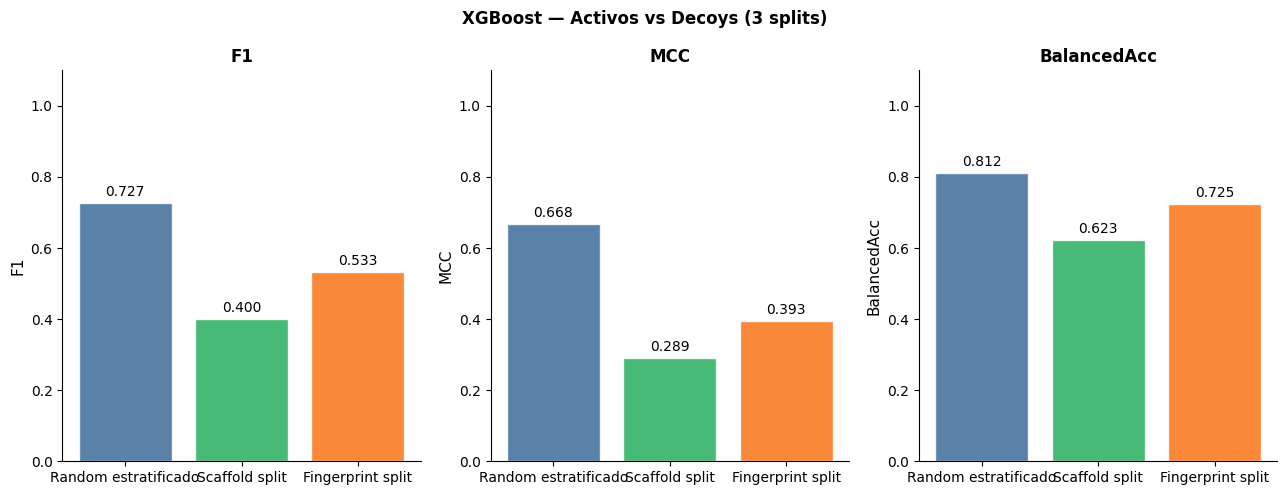

In [62]:
# ── Tabla comparativa de los 3 splits ────────────────────────────────────────
df_resultados_splits = pd.DataFrame(resultados_splits).set_index('Split')
print("COMPARACIÓN DE LOS 3 SPLITS — XGBoost")
print("=" * 50)
print(df_resultados_splits.round(4).to_string())

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
metricas_plot = ['F1', 'MCC', 'BalancedAcc']
colores_split = ['#3d6b99','#27ae60','#f97316']

for ax, metrica in zip(axes, metricas_plot):
    vals = df_resultados_splits[metrica]
    bars = ax.bar(vals.index.tolist(), vals,
                  color=colores_split, alpha=0.85, edgecolor='white')
    ax.set_ylabel(metrica, fontsize=11)
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.3f}', ha='center', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('XGBoost — Activos vs Decoys (3 splits)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/comparacion_splits.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 10. Predicción sobre BitterDB

**BitterDB** ([bitterdb.agri.huji.ac.il](https://bitterdb.agri.huji.ac.il/)) es una base de datos curada de compuestos amargos mantenida por el laboratorio de la Prof. Masha Y. Niv (Universidad Hebrea de Jerusalén). Contiene compuestos con actividad confirmada sobre receptores de sabor amargo (TAS2R), que son GPCRs expresados principalmente en papilas gustativas, pero también en tejidos no gustativos (intestino, pulmón, cerebro).

### ¿Por qué BitterDB como conjunto de prueba?

| Razón | Detalle |
|-------|---------|
| **Bioactivos reales** | Todos los compuestos han sido validados experimentalmente sobre ≥1 TAS2R |
| **Scaffolds diversos** | Alcaloides, terpenoides, flavonoides, péptidos amargos — alta diversidad estructural |
| **Sin overlap con activos** | Ningún compuesto del set de training proviene de BitterDB |
| **Relevancia fisiológica** | Algunos amargos conocidos (capsaicina, quercetina) también modulan TRPV1 |

### Pipeline

```
bitterdb-substances.csv
    ↓ Filtrar por MW dentro del rango de los activos ChEMBL
    ↓ Canonicalizar SMILES con RDKit
    ↓ Seleccionar 50 moléculas (un scaffold único por compuesto)
    ↓ Conformeros 3D + PDBQT (Meeko)
    ↓ Docking Vina (mismos parámetros que activos)
    ↓ ProLIF fingerprints (pose 1)
    ↓ Predicción con los 3 modelos XGBoost
    ↓ Votación mayoritaria (≥2/3 modelos → candidato activo-like)
```


In [63]:
# ── Descargar BitterDB, canonicalizar y seleccionar 50 moléculas ─────────────
URL_BITTER   = ("https://raw.githubusercontent.com/FelPVic/curso_datascience/"
                "main/files/bitterdb-substances.csv")
ARCHIVO_BITTER = 'bitterdb-substances.csv'

if os.path.exists(ARCHIVO_BITTER):
    df_bitter = pd.read_csv(ARCHIVO_BITTER)
    print(f"✅ BitterDB cargado localmente: {len(df_bitter)} compuestos")
else:
    print("Descargando BitterDB desde GitHub...")
    r = requests.get(URL_BITTER, timeout=120)
    if r.status_code == 200:
        with open(ARCHIVO_BITTER, 'wb') as fh:
            fh.write(r.content)
        df_bitter = pd.read_csv(ARCHIVO_BITTER)
        print(f"✅ BitterDB descargado: {len(df_bitter)} compuestos")
    else:
        raise ConnectionError(f"No se pudo descargar BitterDB: HTTP {r.status_code}")

print(f"   Columnas: {df_bitter.columns.tolist()}")

# ── Canonicalizar SMILES con RDKit ────────────────────────────────────────────
def canonicalizar(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

df_bitter['canonical_smiles'] = df_bitter['smiles'].apply(canonicalizar)
df_bitter = df_bitter.dropna(subset=['canonical_smiles']).reset_index(drop=True)
print(f"   Tras canonicalizar: {len(df_bitter)} compuestos válidos")

# ── Filtrar por rango de MW de los activos ChEMBL ────────────────────────────
mw_lo, mw_hi = rangos['MW']
df_bitter['MW_calc'] = df_bitter['canonical_smiles'].apply(
    lambda s: Descriptors.MolWt(Chem.MolFromSmiles(s)) if Chem.MolFromSmiles(s) else np.nan
)
df_bitter_filt = (df_bitter
                  .dropna(subset=['MW_calc'])
                  .query(f"MW_calc >= {mw_lo} and MW_calc <= {mw_hi}")
                  .reset_index(drop=True))

print(f"\nRango MW activos: [{mw_lo:.1f}, {mw_hi:.1f}] Da")
print(f"BitterDB en rango: {len(df_bitter_filt)} / {len(df_bitter)} compuestos")

# ── Seleccionar 50 moléculas (un scaffold único por compuesto) ────────────────
df_bitter_filt['scaffold'] = df_bitter_filt['canonical_smiles'].apply(scaffold_generico)
df_bitter_sel = (df_bitter_filt
                 .dropna(subset=['scaffold'])
                 .drop_duplicates(subset='scaffold')
                 .sample(min(50, len(df_bitter_filt)), random_state=7)
                 .reset_index(drop=True))

df_bitter_sel['bitter_id'] = [f"BITTER_{i:03d}" for i in range(len(df_bitter_sel))]

print(f"\n✅ Moléculas BitterDB seleccionadas: {len(df_bitter_sel)}")
print(f"   Scaffolds únicos: {df_bitter_sel['scaffold'].nunique()}")
print(f"   MW media: {df_bitter_sel['MW_calc'].mean():.1f} Da")
print()
print(df_bitter_sel[['bitter_id', 'MW_calc', 'canonical_smiles']].head(5).to_string(index=False))


Descargando BitterDB desde GitHub...
✅ BitterDB descargado: 1785 compuestos
   Columnas: ['zinc_id', 'smiles']
   Tras canonicalizar: 1785 compuestos válidos

Rango MW activos: [158.3, 900.8] Da
BitterDB en rango: 1599 / 1785 compuestos

✅ Moléculas BitterDB seleccionadas: 50
   Scaffolds únicos: 50
   MW media: 369.1 Da

 bitter_id  MW_calc                                                                        canonical_smiles
BITTER_000  242.362                                                          CCC(C)(S(=O)(=O)CC)S(=O)(=O)CC
BITTER_001  448.380        O=c1c(O[C@@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12
BITTER_002  392.580 C[C@H](CCC(=O)O)[C@H]1CC[C@H]2[C@@H]3[C@H](O)C[C@@H]4C[C@H](O)CC[C@]4(C)[C@H]3CC[C@]12C
BITTER_003  278.304                        CC1=C2C(=O)C=C(CO)[C@@H]2[C@H]2OC(=O)[C@@H](C)[C@@H]2[C@@H](O)C1
BITTER_004  228.185                                                   O=[N+]([O-])c1ccc2c(c1)C(O)=NS2(=O)=O


In [ ]:
# ── Preparar BitterDB: conformeros 3D + PDBQT + docking Vina ─────────────────
bitter_dock_dir = 'docking_bitter'
os.makedirs(bitter_dock_dir, exist_ok=True)

print(f"Preparando {len(df_bitter_sel)} moléculas BitterDB (conformeros + PDBQT)...")
pdbqts_bitter = []
for _, row in tqdm(df_bitter_sel.iterrows(), total=len(df_bitter_sel)):
    pdbqt = preparar_ligando(row['canonical_smiles'])
    pdbqts_bitter.append(pdbqt)

df_bitter_sel['pdbqt'] = pdbqts_bitter
df_bitter_validos = df_bitter_sel[df_bitter_sel['pdbqt'].notna()].reset_index(drop=True)
print(f"✅ Preparadas: {len(df_bitter_validos)} / {len(df_bitter_sel)}")

Preparando 50 moléculas BitterDB (conformeros + PDBQT)...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Preparadas: 49 / 50

Ya procesados: 0  |  Pendientes: 49
Acoplando 49 moléculas BitterDB...


BitterDB docking:   0%|          | 0/49 [00:00<?, ?it/s]

In [ ]:
# ── Docking en batch ──────────────────────────────────────────────────────────
import glob as _glob

ya_proc_b = set(os.path.splitext(os.path.basename(f))[0]
                for f in _glob.glob(f'{bitter_dock_dir}/*.sdf'))
pendientes_b = df_bitter_validos[~df_bitter_validos['bitter_id'].isin(ya_proc_b)]

print(f"\nYa procesados: {len(ya_proc_b)}  |  Pendientes: {len(pendientes_b)}")

if len(pendientes_b) > 0:
    from joblib import Parallel, delayed
    print(f"Acoplando {len(pendientes_b)} moléculas BitterDB...")
    resultados_b = Parallel(n_jobs=min(2, os.cpu_count() or 1), prefer='threads')(
        delayed(vina_docking_decoy)(
            row.bitter_id, row.pdbqt, bitter_dock_dir
        )
        for _, row in tqdm(pendientes_b.iterrows(),
                           total=len(pendientes_b), desc='BitterDB docking')
    )
    print(f"✅ Docking completado: {sum(resultados_b)} / {len(pendientes_b)}")

sdfs_bitter = _glob.glob(f'{bitter_dock_dir}/*.sdf')
print(f"\nSDFs disponibles: {len(sdfs_bitter)}")

In [ ]:
# ── Verificar SDFs bitter y convertir PDBQT→SDF si es necesario ──────────────
import glob as _glob

bitter_id_a_smiles = {row["bitter_id"]: row["canonical_smiles"]
                      for _, row in df_bitter_validos.iterrows()}

sdfs_bitter_disco = _glob.glob(f"{bitter_dock_dir}/*.sdf")
print(f"Verificando {len(sdfs_bitter_disco)} archivos en {bitter_dock_dir}/...")
print("=" * 60)

validos_b, convertidos_b, fallidos_b = 0, 0, 0

for sdf_path in tqdm(sdfs_bitter_disco, desc="Verificando/Convirtiendo bitter"):
    if es_sdf_valido(sdf_path):
        validos_b += 1
        continue
    mol_id = os.path.splitext(os.path.basename(sdf_path))[0]
    smiles = bitter_id_a_smiles.get(mol_id, "")
    ok = pdbqt_a_sdf(sdf_path, smiles, sdf_path)
    if ok:
        convertidos_b += 1
    else:
        fallidos_b += 1
        print(f"  ❌ No se pudo convertir: {os.path.basename(sdf_path)}")

print()
print(f"  ✅ Ya eran SDF válidos:        {validos_b}")
print(f"  🔄 Convertidos (PDBQT → SDF): {convertidos_b}")
print(f"  ❌ Fallidos:                   {fallidos_b}")
print(f"  Total SDF válidos disponibles: {validos_b + convertidos_b}")


In [ ]:
# ── ProLIF para moléculas BitterDB ────────────────────────────────────────────
import glob

sdfs_bitter = glob.glob(f'{bitter_dock_dir}/*.sdf')
print(f"SDFs BitterDB encontrados: {len(sdfs_bitter)}")

fps_bitter_lista = []
for sdf_path in tqdm(sdfs_bitter, desc='ProLIF BitterDB'):
    mol_id = os.path.splitext(os.path.basename(sdf_path))[0]
    fp = get_prolif_fp(sdf_path, mol_id, protein_mol)
    if fp is not None:
        fps_bitter_lista.append(fp)

if fps_bitter_lista:
    fps_bitter_df = pd.concat(fps_bitter_lista).fillna(0)
    print(f"\n✅ ProLIF BitterDB: {fps_bitter_df.shape[0]} moléculas × {fps_bitter_df.shape[1]} interacciones")
else:
    print("⚠️  No se calcularon fingerprints para BitterDB — revisar el docking")
    fps_bitter_df = pd.DataFrame()


---
## 11. Estandarización y predicción final

Aplanamos el MultiIndex de ProLIF (residuo + interacción), alineamos las columnas
de BitterDB con las del training set (imputando 0 donde no hay interacción) y
aplicamos los 3 modelos XGBoost.

**Votación mayoritaria:** una molécula se etiqueta como **candidato activo-like** si
≥ 2 de los 3 modelos predicen clase 1 (activo).

💡 Si compuestos de BitterDB son predichos como activos por el modelo de TRPV1,
puede indicar:
- Cross-reactividad entre vías TAS2R y TRPV1 (ambos involucrados en nocicepción oral)
- Similitud de interacciones en el sitio de unión con los inhibidores de ChEMBL
- Candidatos para validación experimental como moduladores duales de sabor/dolor


# ── Aplanar MultiIndex y alinear columnas con el training set ─────────────────
if not fps_bitter_df.empty:
    fps_bitter_flat = flatten_multiindex_cols(fps_bitter_df.copy())

    cols_train = [c for c in df_combined.columns if c in feature_cols]

    X_bitter      = fps_bitter_flat.reindex(columns=cols_train, fill_value=0).values
    bitter_ids_pred = fps_bitter_flat.index.tolist()

    n_falt = len([c for c in cols_train if c not in fps_bitter_flat.columns])
    print(f"Features del training:       {len(cols_train)}")
    print(f"Features de BitterDB:        {fps_bitter_flat.shape[1]}")
    print(f"Features imputadas con 0:    {n_falt}")
    print(f"X_bitter shape:              {X_bitter.shape}")
else:
    print("⚠️  fps_bitter_df vacío — revisar el docking o ProLIF")
    X_bitter        = np.array([])
    bitter_ids_pred = []


In [ ]:
# ── Predicción con los 3 modelos + votación mayoritaria ──────────────────────
if X_bitter.size > 0:
    preds_bitter  = {}
    probas_bitter = {}

    for nombre, modelo in modelos_splits.items():
        preds_bitter[nombre]  = modelo.predict(X_bitter)
        probas_bitter[nombre] = modelo.predict_proba(X_bitter)[:, 1]

    # Recuperar SMILES desde df_bitter_sel
    id_to_smi_bitter = dict(zip(df_bitter_sel['bitter_id'],
                                 df_bitter_sel['canonical_smiles']))

    df_pred_bitter = pd.DataFrame({
        'bitter_id':            bitter_ids_pred,
        'P_activo_Random':      probas_bitter['Random'].round(3),
        'P_activo_Scaffold':    probas_bitter['Scaffold'].round(3),
        'P_activo_Fingerprint': probas_bitter['Fingerprint'].round(3),
        'Pred_Random':          preds_bitter['Random'],
        'Pred_Scaffold':        preds_bitter['Scaffold'],
        'Pred_Fingerprint':     preds_bitter['Fingerprint'],
    })
    df_pred_bitter['smiles'] = df_pred_bitter['bitter_id'].map(id_to_smi_bitter)

    # Votación mayoritaria: candidato si ≥ 2/3 modelos predicen activo
    df_pred_bitter['votos_activo'] = (
        df_pred_bitter[['Pred_Random', 'Pred_Scaffold', 'Pred_Fingerprint']].sum(axis=1)
    )
    df_pred_bitter['candidato'] = df_pred_bitter['votos_activo'] >= 2

    n_candidatos = df_pred_bitter['candidato'].sum()
    print(f"PREDICCIONES SOBRE BITTERDB ({len(df_pred_bitter)} moléculas)")
    print("=" * 60)
    print(f"  Predichos como activos (≥2/3 modelos): {n_candidatos}")
    print(f"  No activos:                            {len(df_pred_bitter) - n_candidatos}")
    print()

    candidatos_bitter = (df_pred_bitter[df_pred_bitter['candidato']]
                         .sort_values('P_activo_Random', ascending=False))
    if len(candidatos_bitter) > 0:
        print("TOP CANDIDATOS:")
        print(candidatos_bitter[['bitter_id', 'P_activo_Random', 'P_activo_Scaffold',
                                  'P_activo_Fingerprint', 'votos_activo']]
              .to_string(index=False))
    else:
        print("Ningún compuesto BitterDB fue clasificado como activo-like.")
        print("El modelo discrimina bien entre activos TRPV1 y compuestos amargos.")
else:
    print("⚠️  No hay datos de BitterDB para predecir")
    df_pred_bitter    = pd.DataFrame()
    candidatos_bitter = pd.DataFrame()


In [ ]:
# ── Visualizar top candidatos BitterDB con RDKit ─────────────────────────────
from IPython.display import display

if len(candidatos_bitter) > 0:
    mols_cand, legs_cand = [], []
    for _, row in candidatos_bitter.head(12).iterrows():
        mol = Chem.MolFromSmiles(str(row.get('smiles', '')))
        if mol:
            mols_cand.append(mol)
            legs_cand.append(
                f"{row['bitter_id']}\n"
                f"P={row['P_activo_Random']:.2f}/"
                f"{row['P_activo_Scaffold']:.2f}/"
                f"{row['P_activo_Fingerprint']:.2f}"
            )

    if mols_cand:
        img = Draw.MolsToGridImage(
            mols_cand, molsPerRow=4, subImgSize=(300, 250),
            legends=legs_cand, returnPNG=False)
        display(img)
        img.save('results/candidatos_bitterdb.png')
        print(f"✅ Guardado: results/candidatos_bitterdb.png")
    else:
        print("⚠️  No se pudieron renderizar las moléculas candidatas")
else:
    print("⚠️  No hay candidatos para visualizar")


In [ ]:
# ── Visualizar los top candidatos con RDKit ───────────────────────────────────
from IPython.display import display

if 'candidatos' in dir() and len(candidatos) > 0:
    # Recuperar SMILES de los candidatos
    id_a_smi = dict(zip(df_dcm_test['molecule_id'], df_dcm_test['std_smiles']))

    mols_cand, legs_cand = [], []
    for _, row in candidatos.head(12).iterrows():
        smi = id_a_smi.get(row['molecule_id'], '')
        mol = Chem.MolFromSmiles(smi)
        if mol:
            mols_cand.append(mol)
            legs_cand.append(
                f"{row['molecule_id'][:12]}\n"
                f"P={row['P_activo_Random']:.2f}/{row['P_activo_Scaffold']:.2f}"
                f"/{row['P_activo_Fingerprint']:.2f}"
            )

    if mols_cand:
        img = Draw.MolsToGridImage(
            mols_cand, molsPerRow=4, subImgSize=(300, 250),
            legends=legs_cand, returnPNG=False)
        display(img)
        img.save('results/candidatos_dcm_test.png')
        print(f"✅ Guardado: results/candidatos_dcm_test.png")
else:
    print("⚠️  No hay candidatos activos en la muestra de DCM test")


# ── Guardar todos los resultados ─────────────────────────────────────────────
import pickle

# Dataset combinado
df_combined.to_csv('results/dataset_activos_decoys.csv', index=False)

# Métricas de los 3 splits
df_resultados_splits.to_csv('results/metricas_3splits.csv')

# Predicciones BitterDB
if not df_pred_bitter.empty:
    df_pred_bitter.to_csv('results/predicciones_bitterdb.csv', index=False)

# Modelos
for nombre, modelo in modelos_splits.items():
    with open(f'results/xgb_{nombre.lower()}_split.pkl', 'wb') as f:
        pickle.dump(modelo, f, protocol=4)

print("✅ ARCHIVOS GUARDADOS en results/")
print("=" * 50)
for f in sorted(__import__('glob').glob('results/*')):
    tam = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):<45} ({tam:.1f} KB)")


In [ ]:
# ── Guardar todos los resultados ─────────────────────────────────────────────
import pickle

# Dataset combinado
df_combined.to_csv('results/dataset_activos_decoys.csv', index=False)

# Métricas de los 3 splits
df_resultados_splits.to_csv('results/metricas_3splits.csv')

# Predicciones DCM test
if 'df_predicciones_bitter' in dir():
    df_predicciones_bitter.to_csv('results/predicciones_dcm_test.csv', index=False)

# Modelos
for nombre, modelo in modelos_splits.items():
    with open(f'results/xgb_{nombre.lower()}_split.pkl', 'wb') as f:
        pickle.dump(modelo, f, protocol=4)

print("✅ ARCHIVOS GUARDADOS en results/")
print("=" * 50)
for f in sorted(__import__('glob').glob('results/*')):
    tam = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):<45} ({tam:.1f} KB)")


---
## ✅ Resumen del notebook

| Paso | Qué hace | Salida |
|------|----------|--------|
| **2. Scaffolds** | MakeScaffoldGeneric sobre activos ChEMBL | `scaffolds_activos` |
| **3. Decoys** | DCM filtrado por propiedades + scaffold distinto | `df_decoys` |
| **4. Preparación** | Conformeros 3D + PDBQT con Meeko | `pdbqt` por molécula |
| **5. Docking** | Vina batch (mismos params que NB-DOCK-02) | SDFs en `docking_decoys/` |
| **6. ProLIF** | Fingerprints de interacción (pose 1) | `fps_decoys_df` |
| **7. Dataset** | Combinar activos (1) + decoys (0) | `df_combined` |
| **8. Splits** | Random · Scaffold · Fingerprint (80/20) | 3 pares train/test |
| **9. XGBoost** | F1, MCC, Balanced Accuracy por split | `modelos_splits` |
| **10. DCM** | 30 moléculas diversas acopladas y clasificadas | `df_predicciones_dcm` |
| **11. Predicción** | Votación mayoritaria (≥2/3 modelos) | `candidatos` |

### Interpretación de los splits

- **Random** → métrica más optimista (moléculas similares en train y test)
- **Scaffold** → mide generalización a nuevas familias químicas
- **Fingerprint** → mide generalización a regiones alejadas del espacio químico

Si Random >> Scaffold ≈ Fingerprint, el modelo memoriza scaffolds del training.
Si los 3 son similares, el modelo ha aprendido patrones generalizables.
